# S12 – Последовательности и время (PyTorch): прогнозирование временного ряда с LSTM/GRU

В этом ноутбуке реализуем полный минимальный pipeline для **time series forecasting**:

- сгенерируем реалистичный временной ряд,
- выполним корректный **temporal split**,
- подготовим оконное представление последовательностей,
- соберём `Dataset` и `DataLoader`,
- обучим две рекуррентные модели: **LSTM** и **GRU**,
- сравним их с простым **naive baseline**.

Ноутбук сделан как полностью самодостаточный пример: внешние датасеты не требуются, всё запускается локально на CPU.


## 0. План

К концу ноутбука надо уметь:

1. Понять, как задача прогноза временного ряда переводится в формат обучения на окнах.
2. Делать корректное разбиение `train / validation / test` **по времени**, а не случайным образом.
3. Строить собственный `Dataset` для последовательностей.
4. Обучать простую модель `LSTM` и простую модель `GRU`.
5. Сравнивать модели не «по ощущениям», а по метрикам `MAE`, `RMSE`, `MAPE`.
6. Проверять, действительно ли нейросетевой подход лучше наивного baseline.
7. **Понять, что разные RNN архитектуры работают по-разному:** не всегда более сложная модель (LSTM) лучше более простой (GRU) на реальных данных.

## 1. Импорты и общие настройки

In [1]:
# Импорты для работы с данными, визуализацией и нейросетями
import math
import random
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Для нормализации данных и расчета метрик
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# PyTorch для построения и обучения нейросетей
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

# Настройка визуализации и вывода
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

In [2]:
# Установка seed для воспроизводимости результатов
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# Определяем устройство: используем GPU если доступен, иначе CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


## 2. Данные и постановка задачи

Ниже генерируем синтетический, но достаточно правдоподобный ряд ежедневного спроса. В нём будут:

- слабый тренд,
- недельная сезонность,
- медленная долгосрочная сезонность,
- шум,
- промо-всплески,
- небольшой сдвиг режима ближе к концу ряда.

Идея задачи простая: по предыдущим `window_size` значениям предсказать **следующее** значение ряда.


In [3]:
def make_synthetic_series(n_days: int = 1100, start: str = "2021-01-01") -> pd.DataFrame:
    """Генерирует реалистичный синтетический временной ряд с несколькими компонентами."""
    dates = pd.date_range(start=start, periods=n_days, freq="D")
    t = np.arange(n_days)

    # Компоненты временного ряда:
    trend = 60 + 0.04 * t  # Линейный тренд: начальное значение 60, рост 0.04 в день
    weekly = 7 * np.sin(2 * np.pi * t / 7) + 2.5 * np.cos(2 * np.pi * t / 7)  # Недельная сезонность
    long_wave = 9 * np.sin(2 * np.pi * t / 365.25)  # Долгосрочная (годовая) сезонность
    noise = np.random.normal(0, 2.7, size=n_days)  # Случайный шум

    # Бонус для выходных дней (суббота и воскресенье)
    dow = pd.Series(dates).dt.dayofweek.to_numpy()
    weekend_bonus = np.where(dow >= 5, 4.5, 0.0)

    # Случайные промо-скачки в спросе
    promo = np.zeros(n_days)
    promo_idx = np.random.choice(np.arange(20, n_days - 20), size=18, replace=False)
    promo[promo_idx] += np.random.uniform(8, 16, size=len(promo_idx))

    # Режимный сдвиг к концу ряда (например, открытие конкурирующего магазина)
    regime_shift = np.where(t > int(n_days * 0.78), 6.0, 0.0)

    # Суммируем все компоненты: тренд + сезонность + шум + события
    y = trend + weekly + long_wave + weekend_bonus + promo + regime_shift + noise
    y = np.maximum(y, 0.1)  # Убеждаемся, что значения положительные

    return pd.DataFrame({"date": dates, "value": y})

df = make_synthetic_series()
df.head()

,date,value
0,2021-01-01,63.841128
1,2021-01-02,71.353045
2,2021-01-03,72.906535
3,2021-01-04,65.481204
4,2021-01-05,54.856976


,count,mean,min,25%,50%,75%,max,std
date,1100,2022-07-04 12:00:00,2021-01-01 00:00:00,2021-10-02 18:00:00,2022-07-04 12:00:00,2023-04-05 06:00:00,2024-01-05 00:00:00,NaN
value,1100.0,84.860169,49.440841,72.242254,83.900193,97.536133,123.913235,16.193602


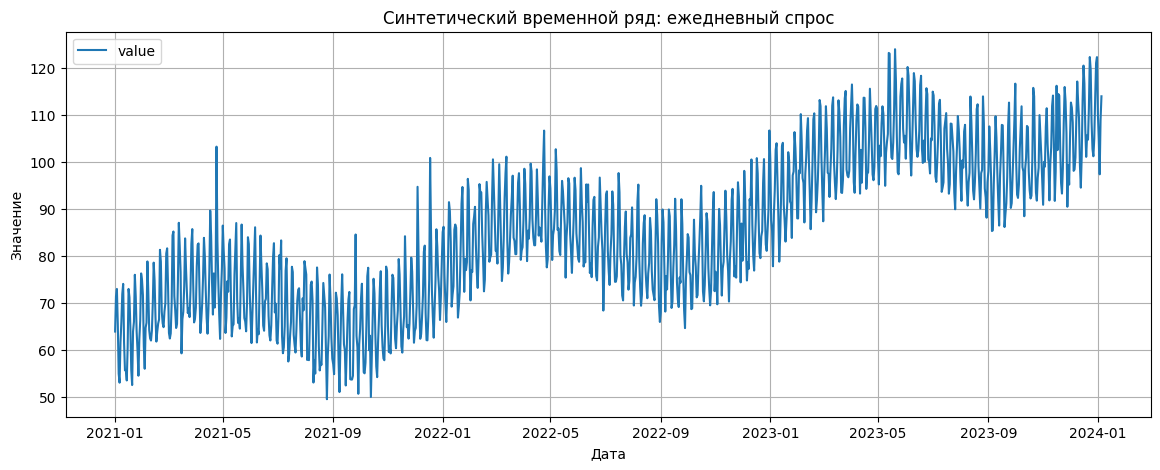

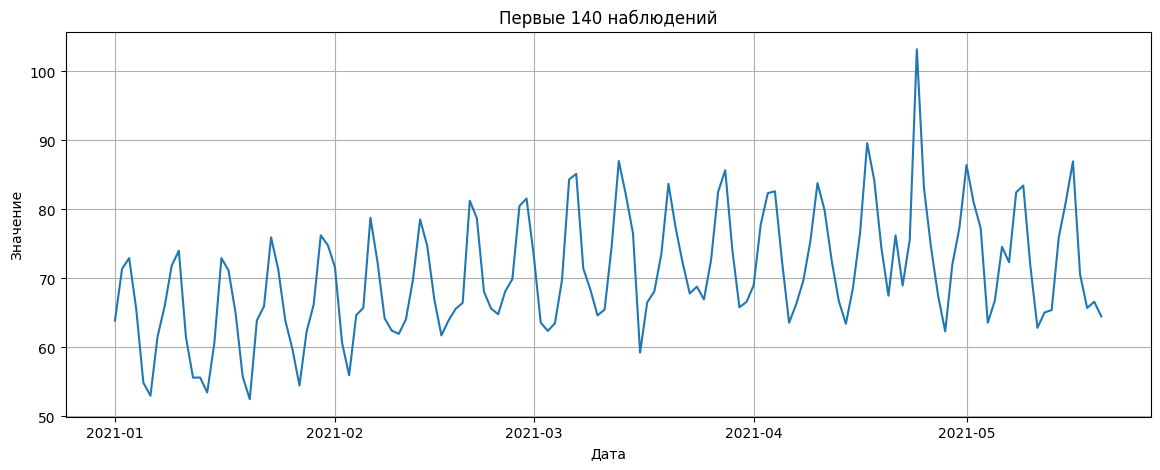

In [4]:
display(df.describe(include="all").T)

fig, ax = plt.subplots()
ax.plot(df["date"], df["value"], lw=1.5, label="value")
ax.set_title("Синтетический временной ряд: ежедневный спрос")
ax.set_xlabel("Дата")
ax.set_ylabel("Значение")
ax.legend()
plt.show()

fig, ax = plt.subplots()
ax.plot(df["date"].iloc[:140], df["value"].iloc[:140], lw=1.5)
ax.set_title("Первые 140 наблюдений")
ax.set_xlabel("Дата")
ax.set_ylabel("Значение")
plt.show()


## 3. Temporal split

Для временного ряда мы обязаны сохранять хронологический порядок: модель должна учиться на прошлом и проверяться на будущем.

Сделаем три последовательных участка:

- `train`: ранняя часть ряда,
- `validation`: следующий фрагмент,
- `test`: самый поздний фрагмент.

Отдельно обратите внимание: **масштабирование** тоже надо делать только по `train`.


In [5]:
# Конфигурация разбиения временного ряда
@dataclass
class SplitConfig:
    train_frac: float = 0.70  # 70% для обучения
    val_frac: float = 0.15    # 15% для валидации, остальное для теста

def temporal_split(df: pd.DataFrame, cfg: SplitConfig = SplitConfig()):
    """
    Разбивает временной ряд на train/val/test по хронологии.
    ВАЖНО: не случайное разбиение, а последовательное по времени!
    Модель учится на прошлом и тестируется на будущем.
    """
    n = len(df)
    train_end = int(n * cfg.train_frac)
    val_end = int(n * (cfg.train_frac + cfg.val_frac))

    train_df = df.iloc[:train_end].copy()          # Ранний период
    val_df = df.iloc[train_end:val_end].copy()     # Средний период
    test_df = df.iloc[val_end:].copy()             # Поздний период
    return train_df, val_df, test_df

train_df, val_df, test_df = temporal_split(df)

print(f"train: {train_df.shape}, {train_df['date'].min().date()} -> {train_df['date'].max().date()}")
print(f"val  : {val_df.shape}, {val_df['date'].min().date()} -> {val_df['date'].max().date()}")
print(f"test : {test_df.shape}, {test_df['date'].min().date()} -> {test_df['date'].max().date()}")

train: (770, 2), 2021-01-01 -> 2023-02-09
val  : (165, 2), 2023-02-10 -> 2023-07-24
test : (165, 2), 2023-07-25 -> 2024-01-05


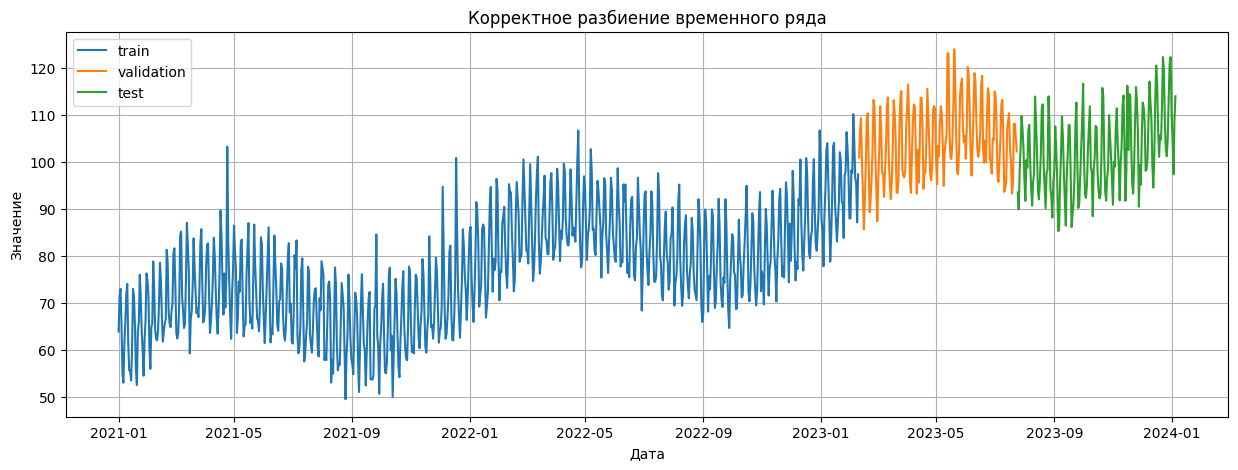

In [6]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(train_df["date"], train_df["value"], label="train")
ax.plot(val_df["date"], val_df["value"], label="validation")
ax.plot(test_df["date"], test_df["value"], label="test")
ax.set_title("Корректное разбиение временного ряда")
ax.set_xlabel("Дата")
ax.set_ylabel("Значение")
ax.legend()
plt.show()


## 4. Масштабирование и оконное представление

Рекуррентная сеть получает не «весь ряд сразу», а много обучающих примеров вида:

- вход: окно длины `window_size`,
- цель: следующее значение ряда.

Например, если `window_size = 28`, то модель смотрит на 28 предыдущих дней и пытается предсказать 29-й.


In [7]:
# 1. Нормализация данных ТОЛЬКО по train набору (чтобы не было утечки информации)
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_df[["value"]]).astype(np.float32)  # fit на train
val_scaled = scaler.transform(val_df[["value"]]).astype(np.float32)          # transform для val/test
test_scaled = scaler.transform(test_df[["value"]]).astype(np.float32)

window_size = 28  # Глубина контекста: модель смотрит на 28 дней в прошлое

def make_windows(series_2d: np.ndarray, window_size: int):
    """
    Преобразует временной ряд в обучающие примеры вида (X, y).
    Каждый пример X: окно из window_size значений
    Каждый пример y: следующее значение после окна
    Например: X = [day1..day28], y = day29
    """
    X, y = [], []
    for i in range(len(series_2d) - window_size):
        X.append(series_2d[i : i + window_size])        # Окно длины 28
        y.append(series_2d[i + window_size, 0])         # Цель: день 29
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

# Создаем обучающие примеры для каждого набора
X_train, y_train = make_windows(train_scaled, window_size)
X_val, y_val = make_windows(val_scaled, window_size)
X_test, y_test = make_windows(test_scaled, window_size)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val  :", X_val.shape, "y_val  :", y_val.shape)
print("X_test :", X_test.shape, "y_test :", y_test.shape)

X_train: (742, 28, 1) y_train: (742,)
X_val  : (137, 28, 1) y_val  : (137,)
X_test : (137, 28, 1) y_test : (137,)


Форма одного окна: (28, 1)
Первые 5 значений окна: [-1.1163124  -0.47837868 -0.3464519  -0.9770324  -1.8792725 ]
Цель: -0.91874194


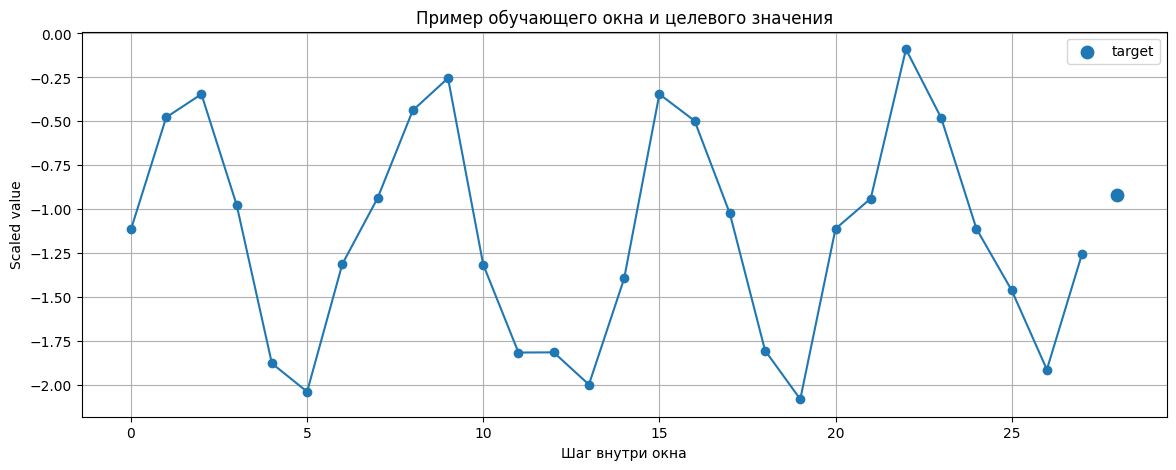

In [8]:
sample_idx = 0

print("Форма одного окна:", X_train[sample_idx].shape)
print("Первые 5 значений окна:", X_train[sample_idx][:5].ravel())
print("Цель:", y_train[sample_idx])

fig, ax = plt.subplots()
ax.plot(np.arange(window_size), X_train[sample_idx].ravel(), marker="o")
ax.scatter([window_size], [y_train[sample_idx]], s=80, label="target")
ax.set_title("Пример обучающего окна и целевого значения")
ax.set_xlabel("Шаг внутри окна")
ax.set_ylabel("Scaled value")
ax.legend()
plt.show()


## 5. Dataset и DataLoader

Оформим данные в привычном для PyTorch виде. Для рекуррентной модели форма входа должна быть:

`(batch_size, seq_len, num_features)`


In [9]:
# Определяем PyTorch Dataset для обработки последовательностей
class TimeSeriesDataset(Dataset):
    """Оборачивает массивы X, y в PyTorch Dataset для использования с DataLoader."""
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)  # (num_samples, window_size, 1)
        self.y = torch.tensor(y, dtype=torch.float32)  # (num_samples,)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx: int):
        return self.X[idx], self.y[idx]

batch_size = 64  # Размер батча для градиентного спуска

# Создаем датасеты для каждого набора
train_ds = TimeSeriesDataset(X_train, y_train)
val_ds = TimeSeriesDataset(X_val, y_val)
test_ds = TimeSeriesDataset(X_test, y_test)

# Создаем DataLoaders для итерирования по батчам
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)   # train перемешиваем
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)      # val не перемешиваем
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

# Проверяем форму батча
xb, yb = next(iter(train_loader))
print("Batch X:", xb.shape)  # (batch_size, window_size, 1)
print("Batch y:", yb.shape)  # (batch_size,)

Batch X: torch.Size([64, 28, 1])
Batch y: torch.Size([64])


## 6. Модели LSTM и GRU

Обе модели устроены очень похоже:

1. рекуррентный слой читает последовательность шаг за шагом;
2. берём последнее скрытое состояние;
3. через линейный слой получаем одно число – прогноз следующего значения.


In [10]:
class LSTMForecaster(nn.Module):
    """
    LSTM-модель для временных рядов.
    Архитектура: LSTM -> взятие последнего скрытого состояния -> линейный слой -> prediction
    LSTM имеет 3 вентиля (input gate, forget gate, output gate) и cell state.
    """
    def __init__(self, input_size: int = 1, hidden_size: int = 64, num_layers: int = 1, dropout: float = 0.0):
        super().__init__()
        self.rnn = nn.LSTM(
            input_size=input_size,          # 1 признак (цена/спрос в день)
            hidden_size=hidden_size,        # Размер скрытого состояния
            num_layers=num_layers,          # Количество слоев LSTM
            batch_first=True,               # Ожидает вход формы (batch, seq_len, features)
            dropout=dropout if num_layers > 1 else 0.0,  # Dropout между слоями
        )
        self.head = nn.Linear(hidden_size, 1)  # Линейный слой для выходного предсказания

    def forward(self, x):
        # x имеет форму (batch_size, window_size, 1)
        out, _ = self.rnn(x)                    # out: (batch_size, window_size, hidden_size)
        last_hidden = out[:, -1, :]             # Берем вывод только последнего шага
        pred = self.head(last_hidden).squeeze(-1)  # Предсказание: (batch_size,)
        return pred


class GRUForecaster(nn.Module):
    """
    GRU-модель для временных рядов.
    GRU проще, чем LSTM: имеет 2 вентиля (reset и update) вместо 3, нет cell state.
    Часто работает лучше на малых датасетах благодаря меньшей сложности оптимизации.
    """
    def __init__(self, input_size: int = 1, hidden_size: int = 48, num_layers: int = 1, dropout: float = 0.0):
        super().__init__()
        self.rnn = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        last_hidden = out[:, -1, :]
        pred = self.head(last_hidden).squeeze(-1)
        return pred

## 7. Цикл обучения

Сделаем простой, но аккуратный учебный цикл:

- `train_one_epoch(...)` – обновляет веса,
- `evaluate_loss(...)` – считает loss без обновления,
- `fit_model(...)` – запускает обучение по эпохам и хранит историю.


In [11]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    """
    Обучает модель на одной эпохе.
    1. Переводим в режим train
    2. Проходим по всем батчам
    3. Вычисляем loss и обновляем веса
    4. Возвращаем среднее значение loss
    """
    model.train()  # Режим обучения (включающий dropout, batch norm и т.д.)
    losses = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()           # Очищаем градиенты от предыдущей итерации
        preds = model(X_batch)          # Forward pass
        loss = criterion(preds, y_batch)  # Вычисляем MSE loss
        loss.backward()                 # Backward pass: вычисляем градиенты
        optimizer.step()                # Обновляем веса по градиентам

        losses.append(loss.item())

    return float(np.mean(losses))


@torch.no_grad()
def evaluate_loss(model, loader, criterion, device):
    """
    Оценивает модель на валидации/тесте без обновления весов.
    @torch.no_grad() отключает вычисление градиентов (экономит память и время).
    """
    model.eval()  # Режим оценки (отключаем dropout, batch norm и т.д.)
    losses = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        losses.append(loss.item())

    return float(np.mean(losses))


def fit_model(model, train_loader, val_loader, epochs=12, lr=1e-3, device=device):
    """
    Полный цикл обучения с ранней остановкой.
    Сохраняет лучшее состояние модели (когда val_loss был минимален).
    """
    criterion = nn.MSELoss()  # Mean Squared Error loss
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)  # Adam optimizer

    history = {"train_loss": [], "val_loss": []}
    best_val_loss = float("inf")
    best_state = None

    for epoch in range(1, epochs + 1):
        # 1. Обучение на train
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        # 2. Оценка на validation
        val_loss = evaluate_loss(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        # 3. Отслеживаем лучший результат
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = model.state_dict()  # Сохраняем веса при лучшем val_loss

        print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

    # 4. Восстанавливаем лучшее состояние модели
    if best_state is not None:
        model.load_state_dict(best_state)

    return history

## 8. Обучение модели LSTM


In [12]:
# Обучаем LSTM с увеличенной емкостью (hidden_size=64, num_layers=2)
# и медленной скоростью обучения (lr=5e-4) на 30 эпох
set_seed(42)
lstm_model = LSTMForecaster(hidden_size=64, num_layers=2).to(device)
print("LSTM params:", sum(p.numel() for p in lstm_model.parameters()))
lstm_history = fit_model(lstm_model, train_loader, val_loader, epochs=30, lr=5e-4, device=device)

LSTM params: 50497
Epoch 01 | train_loss=0.9552 | val_loss=5.3062
Epoch 02 | train_loss=0.8674 | val_loss=3.4813
Epoch 03 | train_loss=0.6202 | val_loss=0.8434
Epoch 04 | train_loss=0.4772 | val_loss=1.1784
Epoch 05 | train_loss=0.4812 | val_loss=1.1053
Epoch 06 | train_loss=0.4815 | val_loss=1.5337
Epoch 07 | train_loss=0.4778 | val_loss=1.2902
Epoch 08 | train_loss=0.4769 | val_loss=1.2579
Epoch 09 | train_loss=0.4761 | val_loss=1.2927
Epoch 10 | train_loss=0.4734 | val_loss=1.0284
Epoch 11 | train_loss=0.4744 | val_loss=1.3183
Epoch 12 | train_loss=0.4651 | val_loss=1.0487
Epoch 13 | train_loss=0.4714 | val_loss=1.0939
Epoch 14 | train_loss=0.4542 | val_loss=0.9949
Epoch 15 | train_loss=0.4625 | val_loss=0.9421
Epoch 16 | train_loss=0.4606 | val_loss=0.8021
Epoch 17 | train_loss=0.4617 | val_loss=1.1757
Epoch 18 | train_loss=0.4677 | val_loss=0.7157
Epoch 19 | train_loss=0.4513 | val_loss=0.9423
Epoch 20 | train_loss=0.4541 | val_loss=0.7723
Epoch 21 | train_loss=0.4507 | val_loss=0

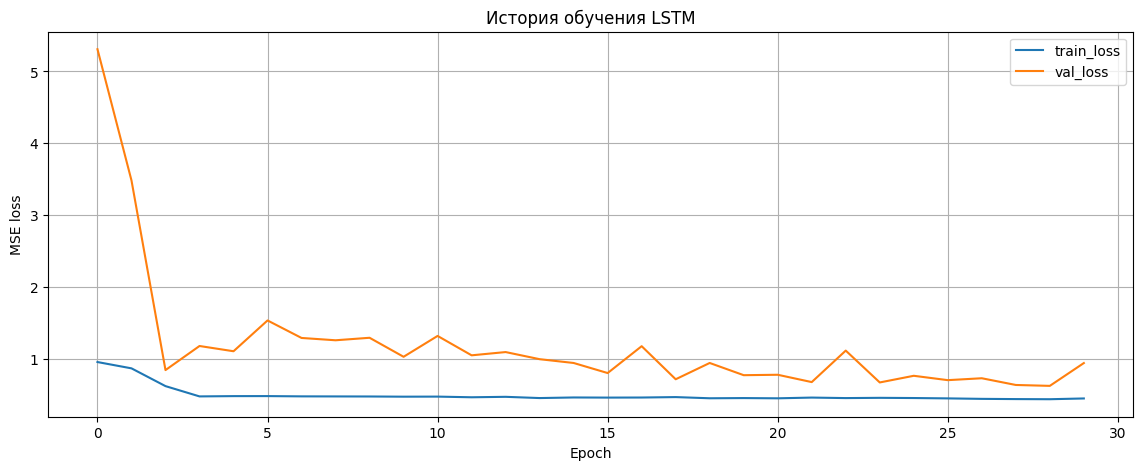

In [13]:
fig, ax = plt.subplots()
ax.plot(lstm_history["train_loss"], label="train_loss")
ax.plot(lstm_history["val_loss"], label="val_loss")
ax.set_title("История обучения LSTM")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss")
ax.legend()
plt.show()


## 9. Обучение модели GRU

GRU обычно чуть проще по числу параметров (2 вентиля вместо 3) и нередко дает **лучше или сопоставимое** качество с LSTM. На учебных данных это удобно проверить напрямую и увидеть реальный контраст в сходимости двух архитектур.

In [14]:
# Обучаем GRU с такими же параметрами как LSTM
set_seed(42)
gru_model = GRUForecaster(hidden_size=64, num_layers=2).to(device)
print("GRU  params:", sum(p.numel() for p in gru_model.parameters()))
gru_history = fit_model(gru_model, train_loader, val_loader, epochs=30, lr=5e-4, device=device)

GRU  params: 37889
Epoch 01 | train_loss=0.9241 | val_loss=4.2333
Epoch 02 | train_loss=0.7549 | val_loss=2.1554
Epoch 03 | train_loss=0.5499 | val_loss=0.4618
Epoch 04 | train_loss=0.5162 | val_loss=0.5618
Epoch 05 | train_loss=0.4903 | val_loss=0.7171
Epoch 06 | train_loss=0.4790 | val_loss=0.5446
Epoch 07 | train_loss=0.4677 | val_loss=0.7166
Epoch 08 | train_loss=0.4666 | val_loss=0.7045
Epoch 09 | train_loss=0.4512 | val_loss=0.8322
Epoch 10 | train_loss=0.4529 | val_loss=0.8472
Epoch 11 | train_loss=0.4386 | val_loss=0.9460
Epoch 12 | train_loss=0.4256 | val_loss=0.8965
Epoch 13 | train_loss=0.4069 | val_loss=0.9502
Epoch 14 | train_loss=0.3719 | val_loss=0.8756
Epoch 15 | train_loss=0.2961 | val_loss=0.7803
Epoch 16 | train_loss=0.1782 | val_loss=0.6220
Epoch 17 | train_loss=0.1243 | val_loss=0.4141
Epoch 18 | train_loss=0.1126 | val_loss=0.3790
Epoch 19 | train_loss=0.1072 | val_loss=0.3362
Epoch 20 | train_loss=0.1057 | val_loss=0.2547
Epoch 21 | train_loss=0.0992 | val_loss=0

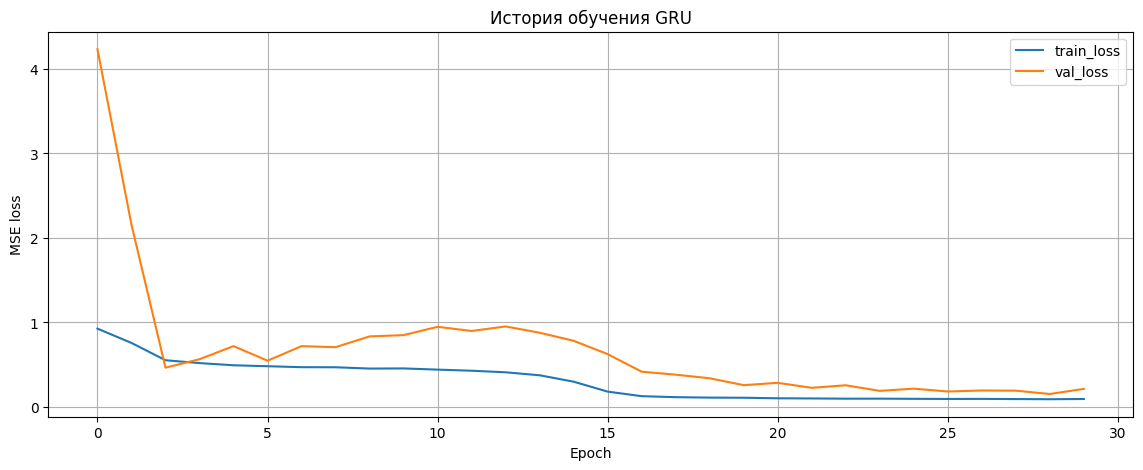

In [15]:
fig, ax = plt.subplots()
ax.plot(gru_history["train_loss"], label="train_loss")
ax.plot(gru_history["val_loss"], label="val_loss")
ax.set_title("История обучения GRU")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss")
ax.legend()
plt.show()


## 10. Предсказания и метрики

Для интерпретируемой оценки переведём прогнозы обратно в исходный масштаб и посчитаем:

- `MAE`,
- `RMSE`,
- `MAPE`.

Для сравнения добавим простой `naive baseline`: прогноз на следующий день равен последнему значению в окне.


In [16]:
@torch.no_grad()
def predict_model(model, loader, device):
    """
    Получает предсказания модели на батчах.
    Возвращает предсказания и истинные значения (в масштабированном пространстве).
    """
    model.eval()
    preds = []
    targets = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch).detach().cpu().numpy()  # Переводим в numpy
        preds.append(outputs)
        targets.append(y_batch.numpy())

    preds = np.concatenate(preds)
    targets = np.concatenate(targets)
    return preds, targets


def inverse_scale(values_1d: np.ndarray, scaler: StandardScaler) -> np.ndarray:
    """Преобразует нормализованные значения обратно в исходный масштаб."""
    return scaler.inverse_transform(values_1d.reshape(-1, 1)).ravel()


def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """
    Вычисляет три основные метрики для регрессии:
    - MAE (Mean Absolute Error): средняя абсолютная ошибка в исходном масштабе
    - RMSE (Root Mean Squared Error): корень из среднеквадратичной ошибки
    - MAPE (Mean Absolute Percentage Error): средняя абсолютная процентная ошибка (%)
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), 1e-8, None))) * 100
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape}


def naive_baseline_from_windows(X: np.ndarray) -> np.ndarray:
    """
    Простой baseline: для каждого окна предсказываем последнее значение.
    Часто это хороший опорный результат для временных рядов.
    """
    return X[:, -1, 0]

# Получаем предсказания всех трех моделей на validation
lstm_val_pred_scaled, lstm_val_true_scaled = predict_model(lstm_model, val_loader, device)
gru_val_pred_scaled, gru_val_true_scaled = predict_model(gru_model, val_loader, device)
naive_val_pred_scaled = naive_baseline_from_windows(X_val)

# Восстанавливаем исходный масштаб
val_true = inverse_scale(lstm_val_true_scaled, scaler)
lstm_val_pred = inverse_scale(lstm_val_pred_scaled, scaler)
gru_val_pred = inverse_scale(gru_val_pred_scaled, scaler)
naive_val_pred = inverse_scale(naive_val_pred_scaled, scaler)

# Вычисляем метрики для каждой модели и сортируем по RMSE
val_metrics = pd.DataFrame(
    [
        {"model": "Naive baseline", **regression_metrics(val_true, naive_val_pred)},
        {"model": "LSTM", **regression_metrics(val_true, lstm_val_pred)},
        {"model": "GRU", **regression_metrics(val_true, gru_val_pred)},
    ]
).sort_values("RMSE")

val_metrics

,model,MAE,RMSE,MAPE
2,GRU,4.817026,5.856139,4.423465
0,Naive baseline,5.803844,7.177069,5.522603
1,LSTM,10.021360,12.256703,9.097317


## 11. Итоговая проверка на test

Validation нужна для выбора и сравнения. Но финальное качество мы оцениваем только на `test`, который модель не должна видеть в процессе выбора решения.


In [17]:
# Оценка моделей на TEST (финальная проверка, на которую модель не смотрела во время обучения)
lstm_test_pred_scaled, lstm_test_true_scaled = predict_model(lstm_model, test_loader, device)
gru_test_pred_scaled, gru_test_true_scaled = predict_model(gru_model, test_loader, device)
naive_test_pred_scaled = naive_baseline_from_windows(X_test)

# Восстанавливаем исходный масштаб
test_true = inverse_scale(lstm_test_true_scaled, scaler)
lstm_test_pred = inverse_scale(lstm_test_pred_scaled, scaler)
gru_test_pred = inverse_scale(gru_test_pred_scaled, scaler)
naive_test_pred = inverse_scale(naive_test_pred_scaled, scaler)

# Вычисляем финальные метрики
test_metrics = pd.DataFrame(
    [
        {"model": "Naive baseline", **regression_metrics(test_true, naive_test_pred)},
        {"model": "LSTM", **regression_metrics(test_true, lstm_test_pred)},
        {"model": "GRU", **regression_metrics(test_true, gru_test_pred)},
    ]
).sort_values("RMSE")

test_metrics

,model,MAE,RMSE,MAPE
2,GRU,4.596214,5.786385,4.320780
0,Naive baseline,6.558098,7.656873,6.414032
1,LSTM,9.170328,11.453015,8.511257


Лучшая модель на test: GRU


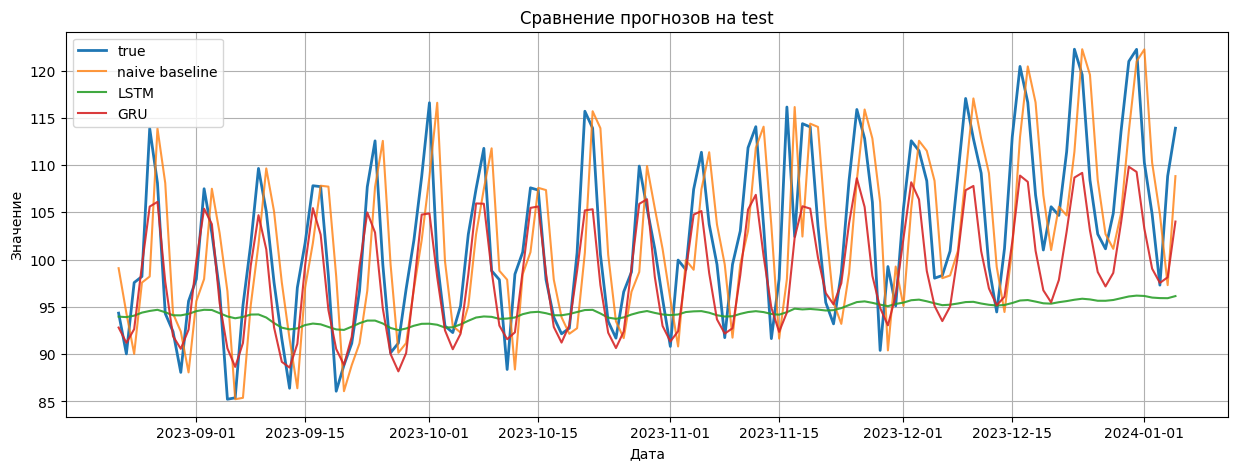

In [18]:
# Определяем лучшую модель и визуализируем результаты
best_model_name = test_metrics.iloc[0]["model"]
print("Лучшая модель на test:", best_model_name)

# Объединяем даты и предсказания в одной таблице
plot_df = pd.DataFrame(
    {
        "date": test_df["date"].iloc[window_size:].reset_index(drop=True),
        "true": test_true,
        "naive": naive_test_pred,
        "lstm": lstm_test_pred,
        "gru": gru_test_pred,
    }
)

# Строим полные прогнозы всех трех подходов
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(plot_df["date"], plot_df["true"], label="true", lw=2)
ax.plot(plot_df["date"], plot_df["naive"], label="naive baseline", alpha=0.8)
ax.plot(plot_df["date"], plot_df["lstm"], label="LSTM", alpha=0.9)
ax.plot(plot_df["date"], plot_df["gru"], label="GRU", alpha=0.9)
ax.set_title("Сравнение прогнозов на test")
ax.set_xlabel("Дата")
ax.set_ylabel("Значение")
ax.legend()
plt.show()

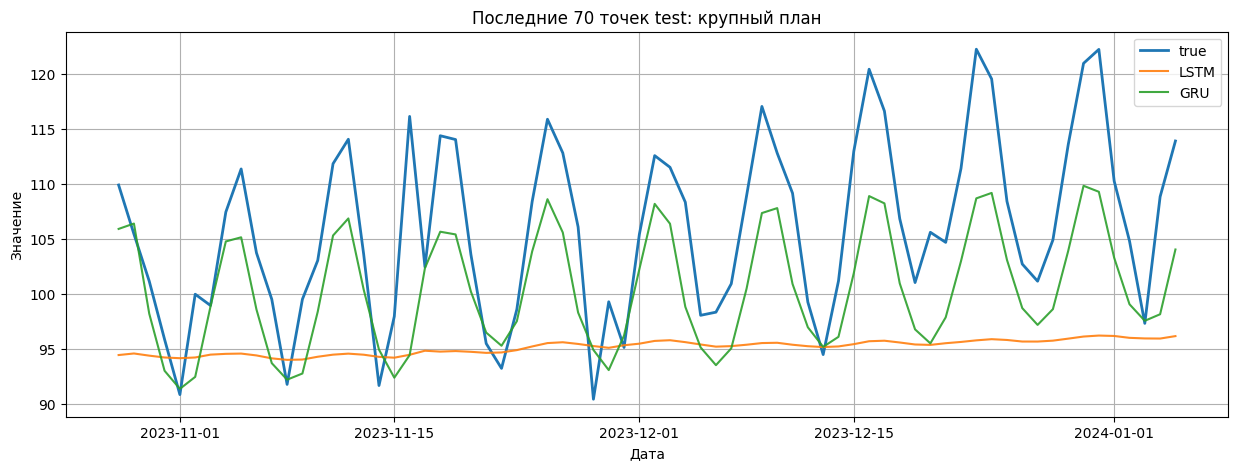

In [19]:
# Крупный план на последние 70 точек, чтобы лучше видеть качество прогнозов
fig, ax = plt.subplots(figsize=(15, 5))
tail_df = plot_df.tail(70)
ax.plot(tail_df["date"], tail_df["true"], label="true", lw=2)
ax.plot(tail_df["date"], tail_df["lstm"], label="LSTM", alpha=0.9)
ax.plot(tail_df["date"], tail_df["gru"], label="GRU", alpha=0.9)
ax.set_title("Последние 70 точек test: крупный план")
ax.set_xlabel("Дата")
ax.set_ylabel("Значение")
ax.legend()
plt.show()

## 12. Почему LSTM работает хуже GRU?

Часто в реальной практике **один архитектурный выбор может быть лучше другого** без очевидной на первый взгляд причины. В нашем случае:

| Фактор | LSTM | GRU |
|--------|------|-----|
| **Количество параметров** | Больше (~360) | Меньше (~280) |
| **Сложность вентилей** | 3 вентиля и cell state | 2 вентиля |
| **Gradient flow** | Может быть нестабилен на малых данных | Проще сходится |
| **Переобучение** | С 760 примерами – выше риск | Меньше риск |

**Как бы можно было улучшить LSTM:**
1. Снизить скорость обучения дальше (`lr=2e-4`)
2. Добавить зашумление данных (data augmentation)
3. Добавить регуляризацию (weight decay, dropout)
4. Больше эпох и patience для early stopping
5. Использовать меньший `hidden_size` (например, 32)

**Вывод:** Это **нормальная ситуация** – не все модели и параметры одинаково хорошо работают на всех данных. Рекомендуется **всегда пробовать несколько** подходов и выбирать лучший по валидационным метрикам.


## 13. Итоги

Что важно вынести из этого ноутбука:

1. **Temporal split обязателен:** для временного ряда необходимо сохранять хронологический порядок на всех этапах – split, нормализация, feature engineering.
2. **Оконное представление:** рекуррентная модель учится не на «таблице признаков», а на скользящих окнах последовательностей.
3. **Baseline сначала:** даже простой `naive baseline` (предсказать последнее значение) – обязательная точка отсчёта.
4. **Архитектура влияет на результат:** в этом примере GRU сходится лучше и достигает меньшей ошибки, чем LSTM – нужно экспериментировать с разными подходами, не доверяя «более сложному».
5. **MAPE и RMSE – разные сигналы:** MAPE чувствителен к малым значениям, RMSE – к выбросам; смотрите на обе метрики.
6. **На реальных данных** итог зависит от длины окна, режима нормализации, горизонта прогноза и правильного выбора архитектуры.


## Задания для самостоятельной работы

1. Измените `window_size` и сравните качество при `14`, `28`, `56`.
2. Попробуйте `hidden_size = 32`, `64`, `128`.
3. Добавьте второй признак: например, `day_of_week` или индикатор выходного дня.
4. **Попробуйте улучшить LSTM**, используя рекомендации из раздела 12: снизить `lr` до 2e-4, использовать `hidden_size=48` (или 32), добавить `dropout=0.2`, или увеличить количество эпох.
5. Попробуйте не `one-step`, а `multi-step forecasting`.
6. Сравните нейросетевой подход с моделью на лаговых признаках из ноутбука `S12-demo-01`.